In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from astropy.io import fits
from matplotlib import colors
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm
from matplotlib.colors import FuncNorm
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
from ellipse import LsqEllipse

In [2]:
import pickle

alma_image = pickle.load(open('alma_image', 'rb'))
alma_image_d = pickle.load(open('alma_image_d', 'rb'))

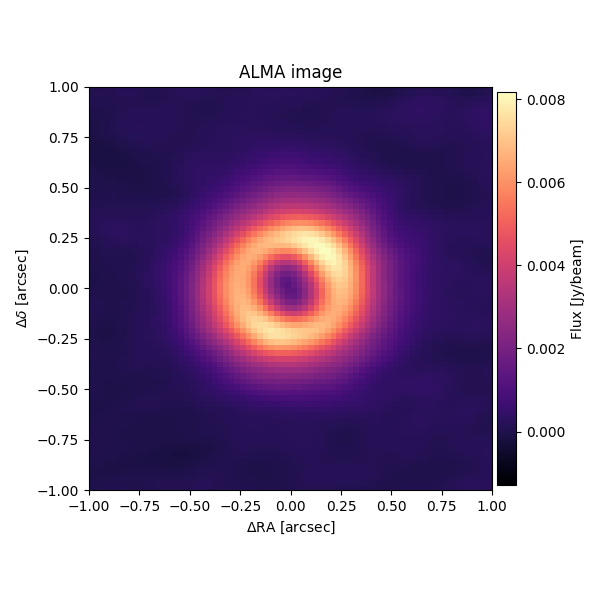

In [3]:
scale = 0.028  # arcsec/px

alma_d_extent = [
    -alma_image.shape[1] * scale / 2 + 0.504,  # Left = -width/2 (as)
    alma_image.shape[1] * scale / 2 + 0.504, # Right = +width/2 (as)
    -alma_image.shape[0] * scale / 2 + 0.112,  # Bottom = -height/2 (as)
    alma_image.shape[0] * scale / 2 + 0.112,   # Top = +height/2 (as)
]

fig, ax = plt.subplots(figsize=(6,6))

ax.set_title('ALMA image')
im = ax.imshow(alma_image_d, origin='lower', cmap='magma', extent=alma_d_extent)
#plt.scatter(0, 0, c='red', edgecolors='black')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01, label=r"Flux [Jy/beam]")
ax.set_xlabel(r'$\Delta$RA [arcsec]')
ax.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-1.0, 1.0)

plt.tight_layout()
plt.show()

In [4]:
# Define a noise region (adjust coordinates to a blank area)
noise_region = alma_image_d[200:300, 400:500]  # Example: top-left corner

# Calculate RMS
rms = np.std(noise_region)
print(f"Estimated RMS noise: {rms:.2e} Jy/beam")

Estimated RMS noise: 1.12e-04 Jy/beam


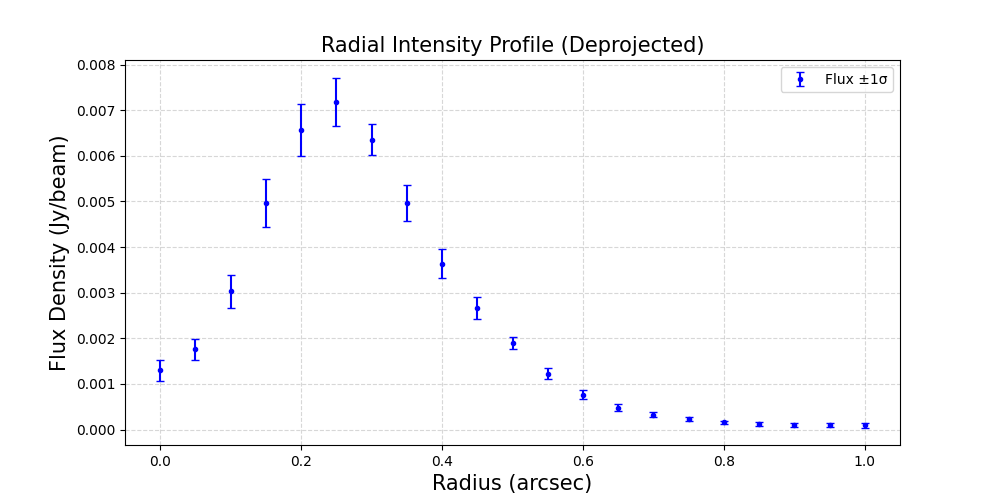

In [5]:
from astropy.io import fits
#from astropy.wcs import WCS
from photutils.aperture import CircularAnnulus, ApertureStats

# User inputs
data = alma_image_d  # Replace with your image data
pixel_scale = 0.028  # arcsec/px
bmaj = 0.194  # Beam major axis (arcsec)
center = (481.4, 495.5)  # Pixel coords of disk center (e.g., (100, 100))

# Radial grid (arcsec)
r_min, r_max = 0.05, 1.0  # Arcsec
r_step = 0.05  # Arcsec
radii_arcsec = np.arange(r_min, r_max + r_step, r_step)
radii_pixels = radii_arcsec / pixel_scale  # Convert to pixels

# Function to calculate sectors per radius
def calculate_sectors(r_arcsec, bmaj):
    delta_theta = 360 * (bmaj / r_arcsec)  # Δθ in degrees
    n_sectors = int(np.round(360 / delta_theta))
    return max(1, n_sectors)  # Ensure ≥1 sector

# Compute radial profile (averaged over all sectors)
radial_profile = []
radial_errors = []  # New: Store errors for each bin
sector_info = []

for r_arcsec, r_px in zip(radii_arcsec, radii_pixels):
    # Calculate sectors
    N_eff = calculate_sectors(r_arcsec, bmaj)
    delta_theta = 360 / N_eff
    
    # Create annulus (1-pixel width)
    annulus = CircularAnnulus(center, (r_arcsec - r_step/4)/pixel_scale, (r_arcsec + r_step/4)/pixel_scale)
    
    # Compute statistics
    stats = ApertureStats(data, annulus)
    
    # Calculate effective independent beams in this annulus
    #circumference_px = 2 * np.pi * r_px
    #bin_area_px = circumference_px * 1  # 1-pixel width
    #beam_area_px = np.pi * (bmaj / (2 * pixel_scale))**2  # Beam area in pixels
    #N_eff = bin_area_px / beam_area_px
    
    # Store results
    radial_profile.append(stats.mean) # average for each bin
    radial_errors.append(stats.std / np.sqrt(N_eff)) # error for each bin
    sector_info.append((r_arcsec, N_eff, delta_theta, stats.std))

# Add flux value at r = 0 arcsec
radial_profile = np.insert(radial_profile, 0, 0.00130)
radii_arcsec = np.insert(radii_arcsec, 0, 0.)
radial_errors = np.insert(radial_errors, 0, radial_errors[0])

# Plot radial profile
plt.figure(figsize=(10, 5))
plt.errorbar(radii_arcsec, radial_profile, yerr=radial_errors,
             fmt='bo', markersize=3, capsize=3, label='Flux ±1σ')
plt.xlabel('Radius (arcsec)', fontsize=15)
plt.ylabel('Flux Density (Jy/beam)', fontsize=15)
plt.title('Radial Intensity Profile (Deprojected)', fontsize=15)
plt.grid(ls='--', alpha=0.5)
plt.legend()
plt.show()

We have measured the **radial intensity profile** using a step $r = 0.05$ so that $r$ covers about two pixels for each step. We remember that for each $r$ we calculated a different **azimuthal angle spacing** $\Delta\theta$, dividing the correspondent annulus in a different number of sectors for each $r$. 

Now, we make a **fit** of the radial intensity profile in order to see what is the peak and the width, and also to build our **ring model** to subtract from the image.

In [6]:
def nuker_profile(r, A, r0, alpha, beta, gamma, r_s):
    return A * ((r+r_s)/r0)**(-gamma) * (1 + ((r+r_s)/r0)**alpha)**((gamma - beta)/alpha)

p0 = [1, 1, 1, 1, 1, 1] 
bounds = ([0, 0, -10, -10, -10, -10], [10, 10, 10, 10, 10, 10])  # Upper bounds prevent runaway values
popt, pcov = curve_fit(nuker_profile, radii_arcsec, radial_profile, sigma=radial_errors,
                          p0=p0, bounds=bounds, maxfev=np.inf)

radial_model = nuker_profile(radii_arcsec, *popt)
chi_squared = np.sum(((radial_profile - radial_model) / radial_errors)**2)
reduced_chi_squared = chi_squared / (len(radial_profile) - len(p0)) 

print (f'{popt[0]: .1e} {popt[1]: .1e} {popt[2]: .1e} {popt[3]: .1e} {popt[4]: .1e} {popt[5]: .1e}')
print ('chi-squared =', chi_squared)
print ('reduced chi-squared =', reduced_chi_squared)

 2.2e-02  8.0e-01  1.0e+01  9.7e+00 -7.2e+00  5.3e-01
chi-squared = 7.283573388524207
reduced chi-squared = 0.48557155923494716


/tmp/ipykernel_2248/3382554363.py:2: RuntimeWarning: invalid value encountered in power
  return A * ((r+r_s)/r0)**(-gamma) * (1 + ((r+r_s)/r0)**alpha)**((gamma - beta)/alpha)


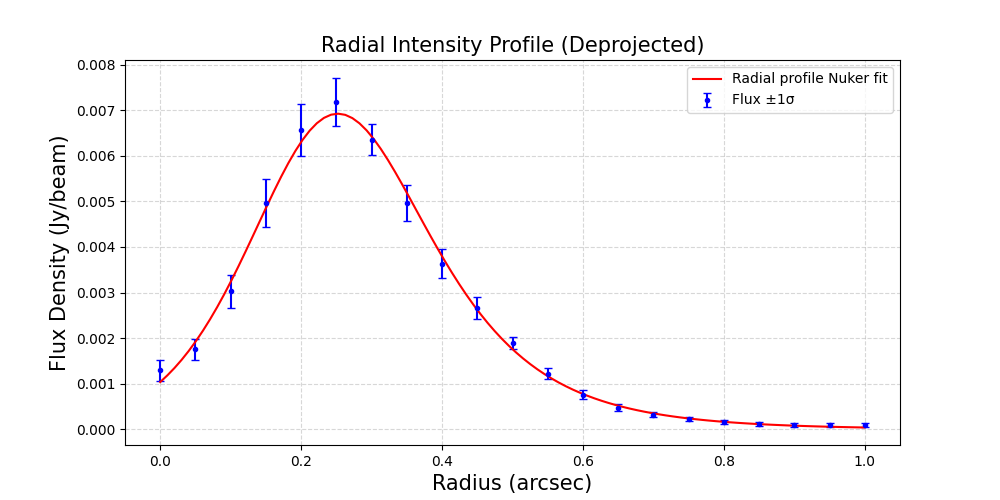

In [7]:
radii_arcsec_fit = np.linspace(0., 1., 100)
#radial_profile_fit = gaussian_powerlaw(radii_arcsec_fit, *popt)
radial_profile_fit = nuker_profile(radii_arcsec_fit, *popt)

plt.figure(figsize=(10, 5))
plt.errorbar(radii_arcsec, radial_profile, yerr=radial_errors,
             fmt='bo', markersize=3, capsize=3, label='Flux ±1σ')
plt.plot(radii_arcsec_fit, radial_profile_fit, 'r-', label='Radial profile Nuker fit')
plt.xlabel('Radius (arcsec)', fontsize=15)
plt.ylabel('Flux Density (Jy/beam)', fontsize=15)
plt.title('Radial Intensity Profile (Deprojected)', fontsize=15)
plt.grid(ls='--', alpha=0.5)
plt.legend()
plt.show()

In [8]:
nuker_profile(0, *popt)

0.00104036831407295

In [9]:
distance = 151 # distance of the disk in pc
peak_position = radii_arcsec_fit[np.argmax(radial_profile_fit)]

print (popt)
print (f'Peak of the azimuthally averaged profile = {peak_position * distance: .1f} AU')

[ 0.02181745  0.8024944  10.          9.65751885 -7.17056263  0.52678526]
Peak of the azimuthally averaged profile =  38.1 AU


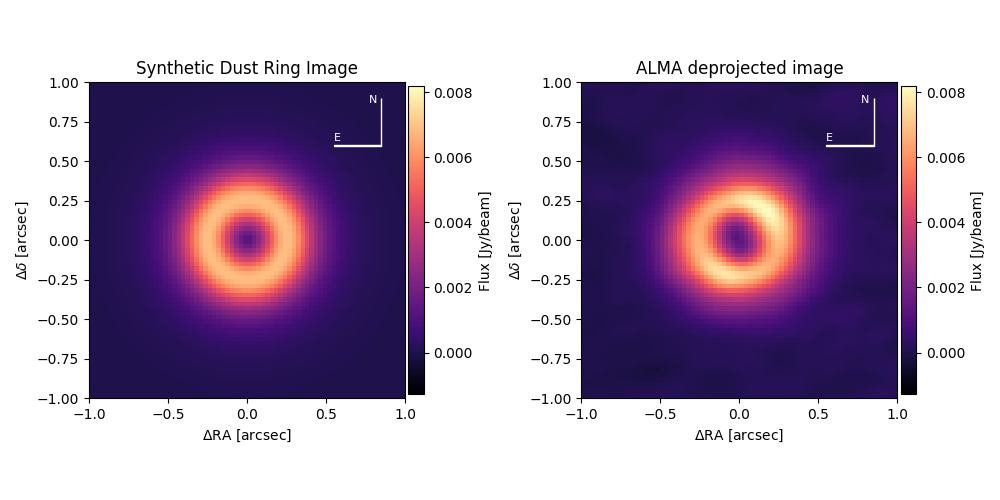

In [10]:
from scipy.interpolate import interp1d

def create_ring_image(radial_profile_r, radial_profile_I, image_size=512, pixel_scale=0.028):
    """
    Create a properly scaled 2D image of a dust ring centered at (0,0).
    
    Parameters:
    - radial_profile_r: array of radii in arcseconds (0.1'' to 1'')
    - radial_profile_I: array of intensities at each radius
    - image_size: output image size in pixels (square)
    - pixel_scale: 0.028 arcseconds/pixel as requested
    
    Returns:
    - 2D numpy array of the dust ring image
    - x and y coordinates in arcseconds
    """
    # Create interpolation function (extrapolate as 0 beyond input range)
    interp_func = interp1d(radial_profile_r, radial_profile_I, 
                         kind='linear', bounds_error=False, fill_value=0.0)
    
    # Create coordinate system centered at (0,0)
    half_size = (image_size - 1) / 2  # for symmetric center
    y, x = np.mgrid[-half_size:half_size+1, -half_size:half_size+1]
    r = np.sqrt(x**2 + y**2) * pixel_scale  # convert to arcseconds
    
    # Create image
    image = interp_func(r)
    
    # Create coordinate arrays in arcseconds
    extent = np.array([-half_size, half_size, -half_size, half_size]) * pixel_scale
    x_arcsec = np.linspace(extent[0], extent[1], image_size)
    y_arcsec = np.linspace(extent[2], extent[3], image_size)
    
    return image, x_arcsec, y_arcsec


# Radius in arcseconds from 0.0'' to 1.0''
r = np.linspace(0., 1., 100)
# Intensity profile
I = nuker_profile(r, *popt)

# Create the image with 0.028''/pixel scale
ring_image, x, y = create_ring_image(r, I, image_size=512, pixel_scale=0.028)

def add_axes(ax, axes_origin_x=0.85, axes_origin_y=0.6, axes_length=0.3, axes_width=0.0004):
    ax.add_patch(patches.Rectangle((axes_origin_x, axes_origin_y), axes_width, axes_length, linewidth=1, edgecolor='white', facecolor='white'))
    ax.add_patch(patches.Rectangle((axes_origin_x - axes_length, axes_origin_y), axes_length, axes_width, linewidth=1, edgecolor='white', facecolor='white'))
    ax.text(axes_origin_x - 0.08, axes_origin_y + axes_length - 0.03, 'N', size=8, color='white')
    ax.text(axes_origin_x - axes_length, axes_origin_y + 0.03, 'E', size=8, color='white')

# Display the image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

extent = [x[0], x[-1], y[0], y[-1]]
im1 = ax1.imshow(ring_image, origin='lower', cmap='magma', extent=extent, vmin=np.nanmin(alma_image_d), vmax=np.nanmax(alma_image_d))
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.01, label=r"Flux [Jy/beam]")
add_axes(ax1)
ax1.set_xlabel(r'$\Delta$RA [arcsec]')
ax1.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax1.set_title('Synthetic Dust Ring Image')
#plt.grid(True, alpha=0.3)
ax1.set_xlim(-1.0, 1.0)
ax1.set_ylim(-1.0, 1.0)

ax2.set_title('ALMA deprojected image')
im2 = ax2.imshow(alma_image_d, origin='lower', cmap='magma', extent=alma_d_extent)
cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.01, label=r"Flux [Jy/beam]")
add_axes(ax2)
ax2.set_xlabel(r'$\Delta$RA [arcsec]')
ax2.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax2.set_xlim(-1.0, 1.0)
ax2.set_ylim(-1.0, 1.0)

plt.tight_layout()
plt.show()

In [11]:
from scipy.interpolate import interp2d

# Create coordinate grids for both images
alma_ra = np.linspace(alma_d_extent[0], alma_d_extent[1], alma_image_d.shape[1])
alma_dec = np.linspace(alma_d_extent[2], alma_d_extent[3], alma_image_d.shape[0])

synth_ra = x  # Your synthetic image RA coordinates (1D array)
synth_dec = y  # Your synthetic image Dec coordinates (1D array)

# Interpolate the synthetic image onto the ALMA grid
interp_func = interp2d(synth_ra, synth_dec, ring_image, kind='linear')
ring_image_regridded = interp_func(alma_ra, alma_dec)

/tmp/ipykernel_2248/551654046.py:11: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  interp_func = interp2d(synth_ra, synth_dec, ring_image, kind='linear')
/tmp/ipykernel_2248/551654046.py:12: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `Linear

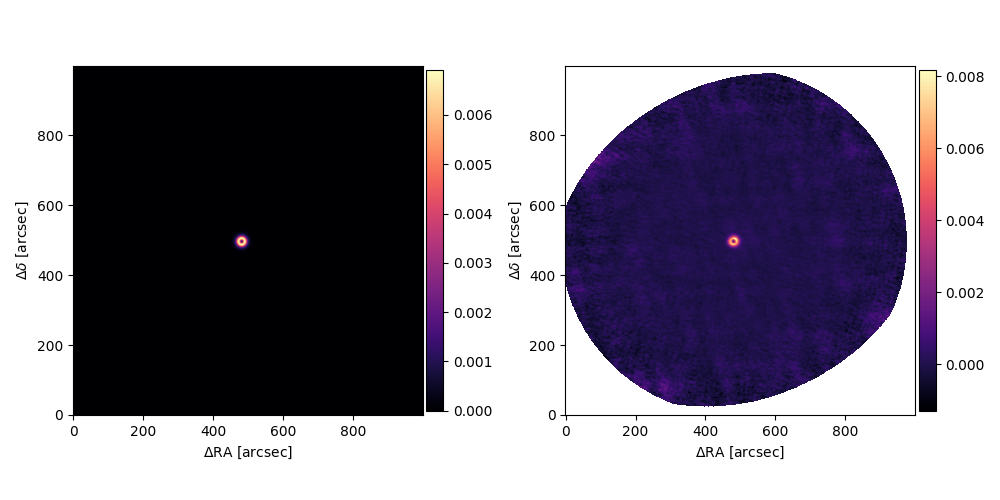

In [12]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(ring_image_regridded, origin='lower', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.01)
plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')

plt.subplot(1, 2, 2)
plt.imshow(alma_image_d, origin='lower', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.01)
plt.xlabel(r'$\Delta$RA [arcsec]')
plt.ylabel(r'$\Delta\delta$ [arcsec]')

plt.tight_layout()
plt.show()

Sum of residuals = 0.9471917910216126


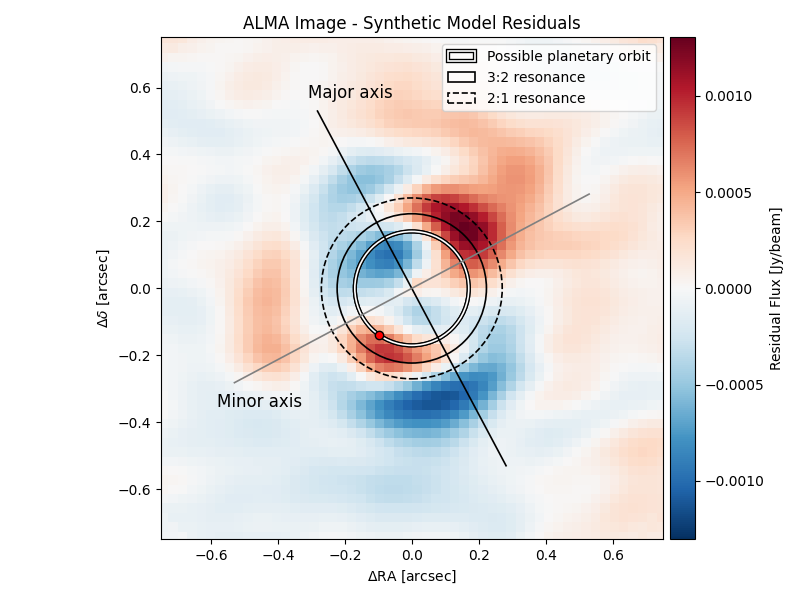

In [13]:
## Compute residuals
residuals = alma_image_d - ring_image_regridded

residuals_sum = np.sum(np.abs(residuals[440:520, 460:540]))
print ('Sum of residuals =', residuals_sum)

# Symmetric vmin/vmax to center zero at white
max_abs = np.nanmax(np.abs(residuals[400:600, 400:600]))  # Scale to largest absolute value

angle_p = 144.66
radius_p = 25.7 # distance of planet in AU
radius_p_arcsec = radius_p / distance
resonance_3_2 = (3./2.)**(2./3.) * radius_p_arcsec
resonance_2_1 = (2./1.)**(2./3.) * radius_p_arcsec

# Planet coordinates
x_planet = radius_p_arcsec * np.cos(np.deg2rad(angle_p + 90))
y_planet = radius_p_arcsec * np.sin(np.deg2rad(angle_p + 90))

def add_circle(ax, radius, edgecolor, linestyle, label):
    circle = plt.Circle((0, 0), radius, edgecolor=edgecolor, facecolor='none', linestyle=linestyle, linewidth=1.2, label=label)
    ax.add_patch(circle)

circle = plt.Circle((0, 0), radius_p_arcsec, 
                   edgecolor='white', 
                   facecolor='none',
                   linewidth=1.2,  # Total line thickness
                   label='Possible planetary orbit')
# Add black outlines using PathEffects
from matplotlib.patheffects import Stroke, Normal
circle.set_path_effects([
    Stroke(linewidth=3, foreground='black'),  # Outer black contour
    Stroke(linewidth=3, foreground='black'),   # Inner black contour
    Normal()                                  # White line
])

# Add straight lines with given position angle
line_length = 0.6
PA = 28.0  # Counter-clockwise from North

# Calculate line endpoints
angle_rad = np.radians(-PA)  # Use positive angle for astronomical convention
x_major = line_length * np.array([-np.sin(angle_rad), np.sin(angle_rad)])
y_major = line_length * np.array([-np.cos(angle_rad), np.cos(angle_rad)])

# Minor axis is perpendicular (PA + 90°)
x_minor = line_length * np.array([-np.sin(angle_rad + np.pi/2), np.sin(angle_rad + np.pi/2)])
y_minor = line_length * np.array([-np.cos(angle_rad + np.pi/2), np.cos(angle_rad + np.pi/2)])

manual_levels = [0.0074]

# Plot residuals
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('ALMA Image - Synthetic Model Residuals')
im = ax.imshow(residuals, origin='lower', cmap='RdBu_r', extent=alma_d_extent,vmin=-max_abs, vmax=max_abs)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01, label=r"Residual Flux [Jy/beam]")
ax.scatter(x_planet, y_planet, c='red', edgecolors='black', zorder=10)
ax.add_patch(circle)
add_circle(ax, resonance_3_2, edgecolor='black', linestyle=None, label='3:2 resonance')
add_circle(ax, resonance_2_1, edgecolor='black', linestyle='--', label='2:1 resonance')

# Plot lines with text labels
ax.plot(x_major, y_major, 'k-', lw=1.2)
ax.plot(x_minor, y_minor, color='gray', lw=1.2)

# Add text labels near the lines
ax.text(x_major[1]*1.1, y_major[1]*1.1, 'Major axis', fontsize=12, ha='left', va='center')
ax.text(x_minor[0]*1.1, y_minor[0]*1.2, 'Minor axis', fontsize=12, ha='left', va='center')

ax.legend(loc='upper right')
ax.set_xlabel(r'$\Delta$RA [arcsec]')
ax.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax.set_xlim(-0.75, 0.75)
ax.set_ylim(-0.75, 0.75)

plt.tight_layout()
plt.show()

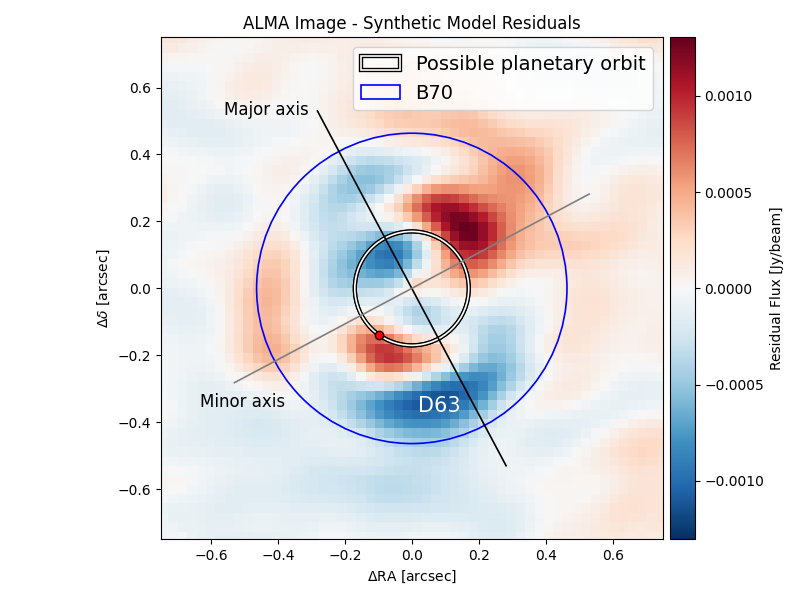

In [35]:
circle = plt.Circle((0, 0), radius_p_arcsec, 
                   edgecolor='white', 
                   facecolor='none',
                   linewidth=1.2,  # Total line thickness
                   label='Possible planetary orbit')
# Add black outlines using PathEffects
from matplotlib.patheffects import Stroke, Normal
circle.set_path_effects([
    Stroke(linewidth=3, foreground='black'),  # Outer black contour
    Stroke(linewidth=3, foreground='black'),   # Inner black contour
    Normal()                                  # White line
])

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('ALMA Image - Synthetic Model Residuals')
im = ax.imshow(residuals, origin='lower', cmap='RdBu_r', extent=alma_d_extent,vmin=-max_abs, vmax=max_abs)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01, label=r"Residual Flux [Jy/beam]")
ax.add_patch(circle)
ax.scatter(x_planet, y_planet, c='red', edgecolors='black', zorder=10)
add_circle(ax, 70/distance, edgecolor='blue', linestyle=None, label='B70')
#add_circle(ax, 0.200, edgecolor='black', linestyle=None, label='Inner ring boundaries')
#add_circle(ax, 0.293, edgecolor='black', linestyle=None, label=None)

# Plot lines with text labels
ax.plot(x_major, y_major, 'k-', lw=1.2)
ax.plot(x_minor, y_minor, color='gray', lw=1.2)

# Add text labels near the lines
ax.text(x_major[1]*1.1 - 0.25, y_major[1]*1.1 - 0.05, 'Major axis', fontsize=12, ha='left', va='center')
ax.text(x_minor[0]*1.1 - 0.05, y_minor[0]*1.2, 'Minor axis', fontsize=12, ha='left', va='center')
ax.text(0.02, -0.37, 'D63', fontsize=15, color='white')

ax.legend(loc='upper right', fontsize=14)
ax.set_xlabel(r'$\Delta$RA [arcsec]')
ax.set_ylabel(r'$\Delta\delta$ [arcsec]')
ax.set_xlim(-0.75, 0.75)
ax.set_ylim(-0.75, 0.75)

plt.tight_layout()
plt.show()